# Erase gender from embeddings — locally — and debias search

Gender is a **low-rank protected attribute**: one or two yes/no questions span it, so **laya**
(local, open-weights) scores it on-device and **LEACE** removes it in closed form. Fully local — no
API, nothing leaves the machine.

We use the open-source **`bias_in_bios`** dataset (professional bios with gender labels), erase the
gender signal, and show the payoff for **retrieval**: a profession query that was gender-skewed
returns a gender-balanced set once you search over the erased embeddings.

In [1]:
import json, hashlib, urllib.request
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import normalize
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import cross_val_predict, StratifiedKFold
from sklearn.decomposition import PCA

CACHE = Path('.gender_cache'); CACHE.mkdir(exist_ok=True)
def dg(x): return hashlib.sha256(json.dumps(x, sort_keys=True, ensure_ascii=False).encode()).hexdigest()
SEED = 0

## 1. Real data (`bias_in_bios`, balanced by gender)

In [2]:
df = CACHE / 'bios_bal.json'
if df.exists():
    rows = json.load(open(df))
else:
    fem, male = [], []
    for off in range(0, 3000, 100):
        url = (f"https://datasets-server.huggingface.co/rows?dataset=LabHC/bias_in_bios"
               f"&config=default&split=train&offset={off}&length=100")
        j = json.load(urllib.request.urlopen(urllib.request.Request(url, headers={"User-Agent": "x"}), timeout=30))
        for r in j["rows"]:
            t = r["row"]["hard_text"].strip().replace("\n", " ")[:600]; g = int(r["row"]["gender"])
            if len(t) >= 40:
                (fem if g == 1 else male).append({"text": t, "female": g})
        if len(fem) >= 150 and len(male) >= 150: break
    n = min(150, len(fem), len(male)); rows = fem[:n] + male[:n]; json.dump(rows, open(df, 'w'))

texts = [r["text"] for r in rows]; gnd = np.array([r["female"] for r in rows])
print(f"{len(texts)} bios  ·  {int(gnd.sum())} female / {int((1-gnd).sum())} male")

300 bios  ·  150 female / 150 male


## 2. Local embeddings (offline)

In [3]:
ef = CACHE / f"emb_{dg(texts)}.npy"
if ef.exists():
    X = np.load(ef)
else:
    from sentence_transformers import SentenceTransformer
    X = SentenceTransformer('all-MiniLM-L6-v2').encode(texts, batch_size=32, show_progress_bar=False)
    np.save(ef, X)
X = normalize(np.asarray(X, float)); print("local embeddings:", X.shape)

local embeddings: (300, 384)


## 3. Erase gender — laya (local) + LEACE

Two yes/no questions span the concept; the linear-probe AUC should fall from ~1.0 to chance.

In [4]:
from jevu import ConceptScrubber, LayaLabeler
GENDER_Q = ["Does the text describe a woman or a female person?",
            "Does the text describe a man or a male person?"]
scr = ConceptScrubber(labeler=LayaLabeler(questions=GENDER_Q, cache_dir=str(CACHE), batch_size=8))
X_clean = scr.fit_transform(X, texts=texts)

def probe_auc(M):
    P = cross_val_predict(LogisticRegression(max_iter=2000), M, gnd,
                          cv=StratifiedKFold(5, shuffle=True, random_state=SEED), method='predict_proba')[:, 1]
    return roc_auc_score(gnd, P)
print(f"gender-probe AUC   before: {probe_auc(X):.3f}")
print(f"gender-probe AUC   after : {probe_auc(X_clean):.3f}   (chance = 0.5)")

gender-probe AUC   before: 0.986
gender-probe AUC   after : 0.109   (chance = 0.5)


## 4. PCA — the gender axis collapses

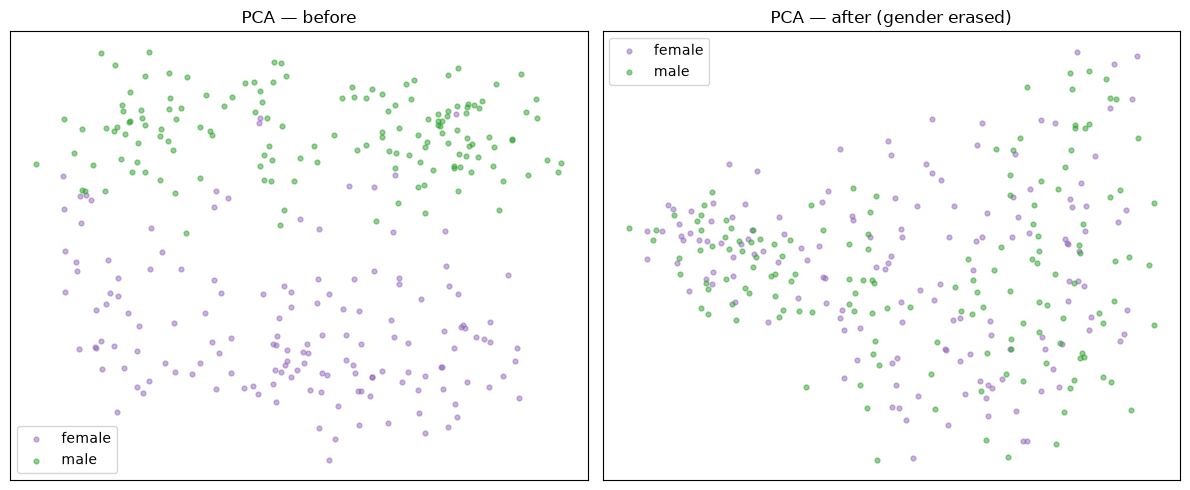

In [5]:
PB = PCA(2, random_state=SEED).fit_transform(X)
PA = PCA(2, random_state=SEED).fit_transform(X_clean)
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
for axi, (P, ttl) in zip(ax, [(PB, 'before'), (PA, 'after (gender erased)')]):
    for g, c, name in [(1, 'tab:purple', 'female'), (0, 'tab:green', 'male')]:
        m = gnd == g; axi.scatter(P[m, 0], P[m, 1], s=12, alpha=0.5, c=c, label=name)
    axi.set_title(f'PCA — {ttl}'); axi.set_xticks([]); axi.set_yticks([]); axi.legend()
plt.tight_layout(); plt.show()

## 5. Debias search — same queries, erased embeddings

Search over the **erased** embeddings: a profession query that used to return a gender-skewed set now
returns a balanced one. We measure the fraction of female bios in the top-10 (50% = balanced). The
query is erased with the *same* map so docs and query live in the same space.

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

top-10 %female  before 90%  →  after 40%   ·  'a registered nurse providing patient care'
top-10 %female  before 30%  →  after 60%   ·  'a university professor'


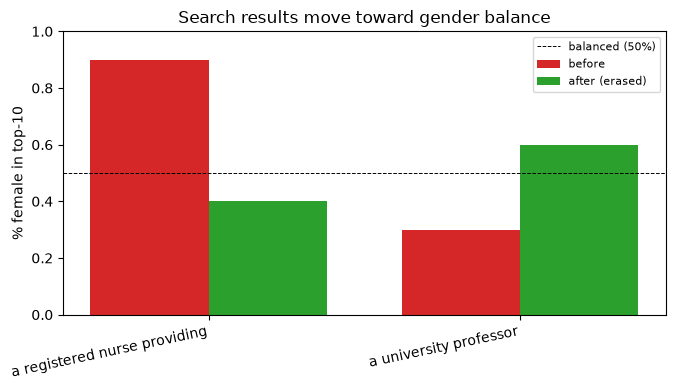

In [6]:
from sentence_transformers import SentenceTransformer
embed = SentenceTransformer('all-MiniLM-L6-v2')
QUERIES = ["a registered nurse providing patient care", "a university professor"]
labels, before, after = [], [], []
for q in QUERIES:
    qv = normalize(embed.encode([q]).astype(float))[0]
    tb = gnd[np.argsort(-(X @ qv))[:10]].mean()
    qa = scr.transform(qv.reshape(1, -1))[0]
    ta = gnd[np.argsort(-(X_clean @ qa))[:10]].mean()
    labels.append(q[:28]); before.append(tb); after.append(ta)
    print(f"top-10 %female  before {tb:.0%}  →  after {ta:.0%}   ·  {q!r}")

x = np.arange(len(labels)); w = 0.38
plt.figure(figsize=(7, 4))
plt.bar(x - w/2, before, w, label='before', color='tab:red')
plt.bar(x + w/2, after, w, label='after (erased)', color='tab:green')
plt.axhline(0.5, ls='--', c='k', lw=0.7, label='balanced (50%)')
plt.xticks(x, labels, rotation=12, ha='right'); plt.ylabel('% female in top-10'); plt.ylim(0, 1)
plt.title('Search results move toward gender balance'); plt.legend(fontsize=8); plt.tight_layout(); plt.show()

## 6. Takeaways

- **Fully local / private.** Local embeddings + local laya + numpy LEACE — nothing leaves the machine.
- **Gender is low-rank** — two questions drive the probe to chance (≈1.0 → 0.1).
- **Debiased retrieval for free:** search over the erased embeddings; the eraser is a fixed matrix, so
  new queries are scrubbed with `scr.transform(q)` — no laya at query time.
- **Effect is largest where ranking *was* gender-skewed** (a "nurse" query), and leaves already-neutral
  queries untouched — it removes the bias, not the relevance.

> Same recipe for any low-rank protected attribute (age, sentiment): swap the two questions. For
> *excluding* unsafe content (a different goal), see `nsfw_erasure.ipynb` (keep the signal, gate on it).